First 5 rows of the dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450

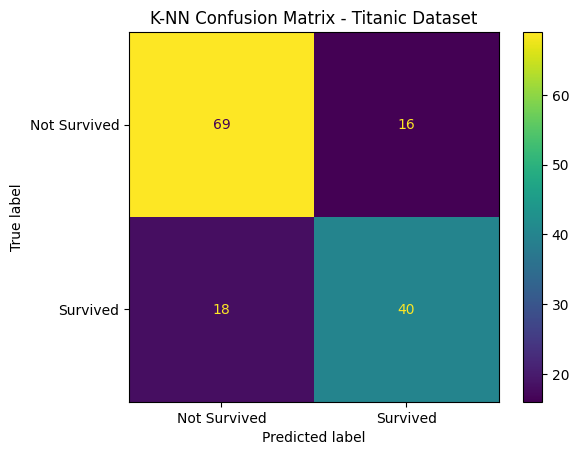

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# --------------------------------------------------
# Loading the Dataset
# --------------------------------------------------

dataset = pd.read_csv("train.csv")

print("First 5 rows of the dataset:")
print(dataset.head())

print("\n" + "=" * 60)

# --------------------------------------------------
# Selecting Required Columns
# --------------------------------------------------

dataset = dataset[
    [
        "Survived",
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare"
    ]
]

# Removing rows with missing values
dataset = dataset.dropna()

# --------------------------------------------------
# Converting Sex into Numerical Values
# --------------------------------------------------

encoder = LabelEncoder()

dataset["Sex"] = encoder.fit_transform(dataset["Sex"])

print("Dataset after preprocessing:")
print(dataset.head())

print("\n" + "=" * 60)

# --------------------------------------------------
# Separating Input Features and Target
# --------------------------------------------------

X = dataset.drop("Survived", axis=1)

y = dataset["Survived"]

print("Number of samples:", len(dataset))

print("\n" + "=" * 60)

# --------------------------------------------------
# Splitting into Training and Testing Data
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# --------------------------------------------------
# Feature Scaling
# --------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# --------------------------------------------------
# Creating and Training the K-NN Model
# --------------------------------------------------

k = 5

model = KNeighborsClassifier(
    n_neighbors=k
)

model.fit(X_train, y_train)

print("K-NN Model Trained Successfully!")
print("Number of Neighbors (K):", k)

print("\n" + "=" * 60)

# --------------------------------------------------
# Making Predictions
# --------------------------------------------------

y_pred = model.predict(X_test)

print("Predicted Results:")
print(y_pred)

print("\nActual Results:")
print(y_test.values)

print("\n" + "=" * 60)

# --------------------------------------------------
# Evaluating the Model
# --------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy * 100, "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\n" + "=" * 60)

# Classification Report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Survived", "Survived"]
    )
)

# --------------------------------------------------
# Visualizing the Confusion Matrix
# --------------------------------------------------

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

display.plot()

plt.title("K-NN Confusion Matrix - Titanic Dataset")

plt.show()